<a href="https://colab.research.google.com/github/RosarioH10062002/M2_master_thesis/blob/main/Data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
ROOT_PATH = "/content/drive/My Drive/M2_Project_Master/Documents/Participants data/"

In [3]:
N_participants = 2
participants = [f"ID{x+1}" for x in range(N_participants)]

#LOAD DATA

In [11]:
root_id1 = ROOT_PATH + "ID1/BASELINE_ID1_20260309_101050.csv"
df_id1 = pd.read_csv(root_id1, sep = ";")
root_id2 = ROOT_PATH + "ID2/BASELINE_ID2_20260309_112213.csv"
df_id2 = pd.read_csv(root_id2, sep = ",")
root_id3 = ROOT_PATH + "ID3/BASELINE_ID3_20260309_222242.csv"
df_id3 = pd.read_csv(root_id3, sep = ",")
root_id4 = ROOT_PATH + "ID4/BASELINE_ID4_20260310_091122.csv"
df_id4 = pd.read_csv(root_id4, sep = ",")

In [10]:
#df_id2["rt(s)"]

#FIRST SESSION PLOTS



In [6]:
def clean_all_data(df):
  df = df.drop(["fc(hz)", "fb(hz)"], axis = 1)
  df["rt(s)"] = df["rt(s)"].fillna(0) # if they didnt answer, I am filling with 0
  df["trial"] = range(df.shape[0])
  return df

def plot_reaccion_time(df, id):
  x_values = df["trial"]
  y_values = df["rt(s)"]

  plt.figure(figsize=(20, 6))
  plt.plot(x_values, y_values)
  plt.xlabel("Trial Number")
  plt.ylabel("Reaction Time (s)")
  plt.title(f"Reaction Time per Trial - ID{id}")
  plt.grid(True)

  plt.axvline(x=44, color='g', linestyle='--', label='Trial Phase')
  plt.axvline(x = 134, color='r', linestyle='--', label='Block 1 - Main Phase')
  plt.axvline(x = 224, color='r', linestyle='--', label='Block 2 - Main Phase')
  plt.axvline(x = 314, color='r', linestyle='--', label='Block 3 - Main Phase')
  plt.axvline(x = 404, color='r', linestyle='--', label='Block 4 - Main Phase')
  plt.axvline(x = 494, color='r', linestyle='--', label='Block 5 - Main Phase')
  plt.axvline(x = 584, color='r', linestyle='--', label='Block 6 - Main Phase')
  plt.legend()

  plt.show()

def compute_accuracy(df, trial):
  df_go_trials = df[df["stimulus_type"] == "Go"]
  n_total_go = df_go_trials.shape[0]
  #print(n_total_go)
  n_correct_go = df_go_trials[df_go_trials["correct"] == "Correct"].shape[0]
  accuracy_go = n_correct_go / n_total_go if n_total_go > 0 else 0

  df_no_go_trials = df[df["stimulus_type"] == "No_go"]
  n_total_no_go = df_no_go_trials.shape[0]
  #print(n_total_no_go)
  n_correct_no_go = df_no_go_trials[df_no_go_trials["correct"] == "Correct"].shape[0]
  accuracy_no_go = n_correct_no_go / n_total_no_go if n_total_no_go > 0 else 0

  #print(f"Accuracy Go: {accuracy_go} \nAccuracy No Go: {accuracy_no_go}")
  return accuracy_go, accuracy_no_go

def compute_both_accuracy(df):
  [accuracy_go, accuracy_no_go] = compute_accuracy(df = df[0:45], trial = True) # trial
  all_accuracy_data = []
  all_accuracy_data.append({"Phase": "Trial", "Accuracy Go": accuracy_go, "Accuracy No Go": accuracy_no_go})

  for block in range(6):
    start = 45 + block*90
    end = start + 90
    #print(f"start: {start}, end {end}")
    [accuracy_go, accuracy_no_go] = compute_accuracy(df = df[start:end], trial = False)
    all_accuracy_data.append({"Phase": f"Block {block+1}", "Accuracy Go": accuracy_go, "Accuracy No Go": accuracy_no_go})
  return all_accuracy_data

def plot_accuracy(data, id):
  labels = [data[x].get("Phase") for x in range(7)]
  list_accuracy_go = [data[x].get("Accuracy Go") for x in range(7)]
  #print(list_accuracy_go)
  list_accuracy_no_go = [data[x].get("Accuracy No Go") for x in range(7)]
  plt.figure(figsize=(20, 6))
  plt.plot(labels, list_accuracy_go)
  plt.xlabel("Phase")
  plt.ylabel("Accuracy (%)")
  plt.title(f"Accuracy Go per Trial - ID{id}")
  plt.grid(True)
  plt.show()

  plt.figure(figsize=(20, 6))
  plt.plot(labels, list_accuracy_no_go)
  plt.xlabel("Phase")
  plt.ylabel("Accuracy (%)")
  plt.title(f"Accuracy No Go per Trial - ID{id}")
  plt.grid(True)
  plt.show()

def split_data(df):
  trial = df[df["block_index"].isna()]
  block_1 = df[df["block_index"] == "1"]
  block_2 = df[df["block_index"] == "2"]
  block_3 = df[df["block_index"] == "3"]
  block_4 = df[df["block_index"] == "4"]
  block_5 = df[df["block_index"] == "5"]
  block_6 = df[df["block_index"] == "6"]
  return trial, block_1,block_2,block_3,block_4,block_5,block_6

def plot_variability_rt(df, id): # variability = std(rt_1block)
  [trial, block_1,block_2,block_3,block_4,block_5,block_6] = split_data(df)
  std_trial = np.std(trial["rt(s)"])
  std_block_1 = np.std(block_1["rt(s)"])
  std_block_2 = np.std(block_2["rt(s)"])
  std_block_3 = np.std(block_3["rt(s)"])
  std_block_4 = np.std(block_4["rt(s)"])
  std_block_5 = np.std(block_5["rt(s)"])
  std_block_6 = np.std(block_6["rt(s)"])

  y_vals = [std_trial,std_block_1,std_block_2,std_block_3,std_block_4,std_block_5,std_block_6]
  print(y_vals)
  x_vals = ["Trial"] + [f"Block {i+1}" for i in range(6)]
  plt.figure(figsize=(20, 6))
  plt.plot(x_vals, y_vals)
  plt.xlabel("Phases")
  plt.ylabel("std(Reaction Time (s))")
  plt.title(f"Reaction Time Variability - ID{id}")
  plt.grid(True)
  plt.show()
  return 0

def plot_commision_errors(df):
  return 0

#ID1

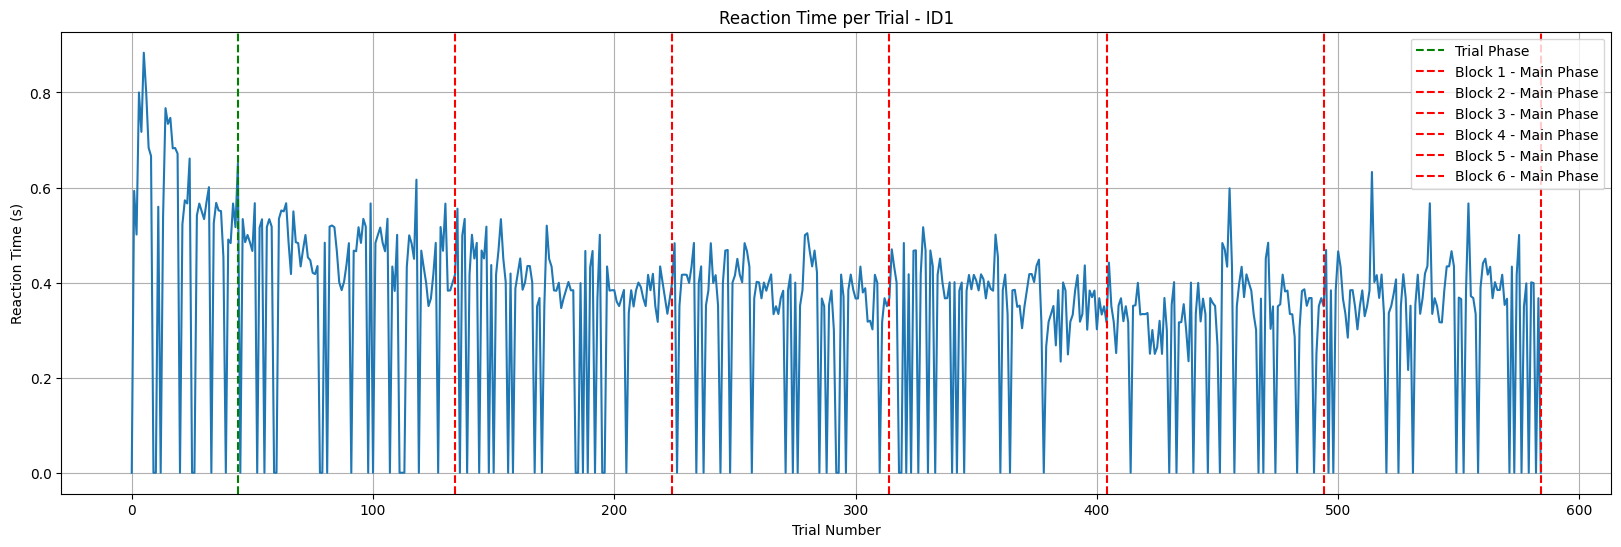

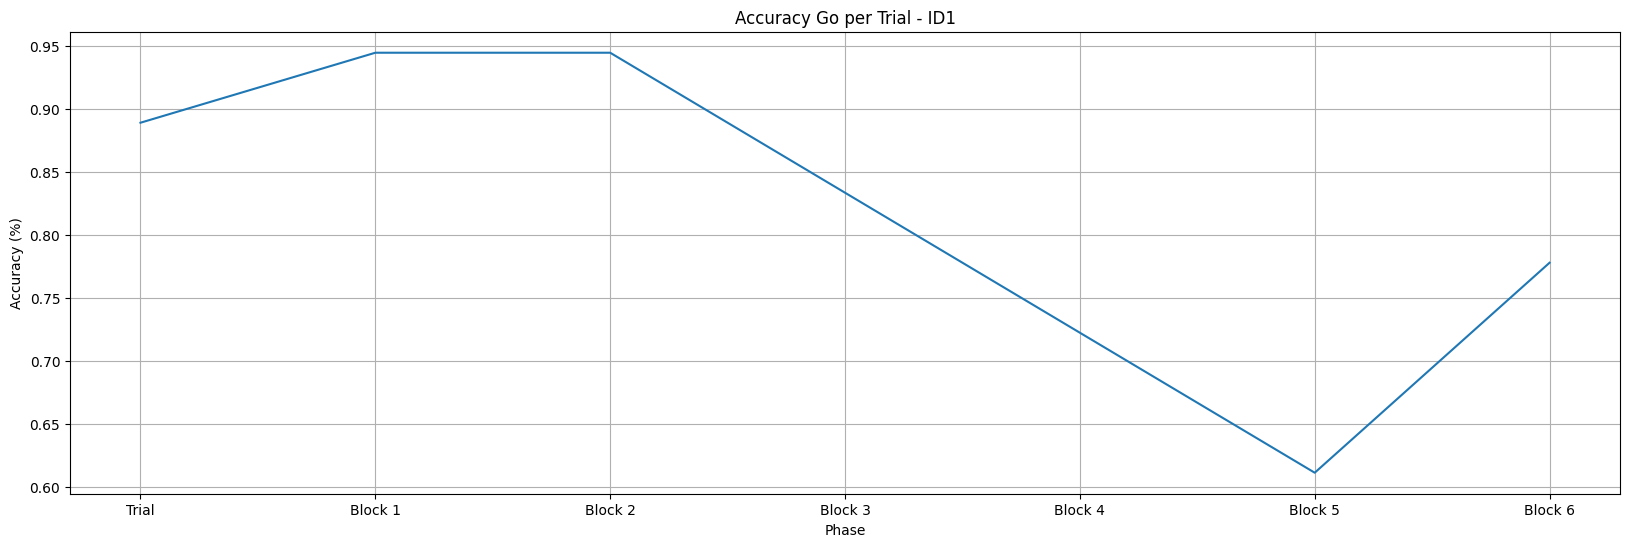

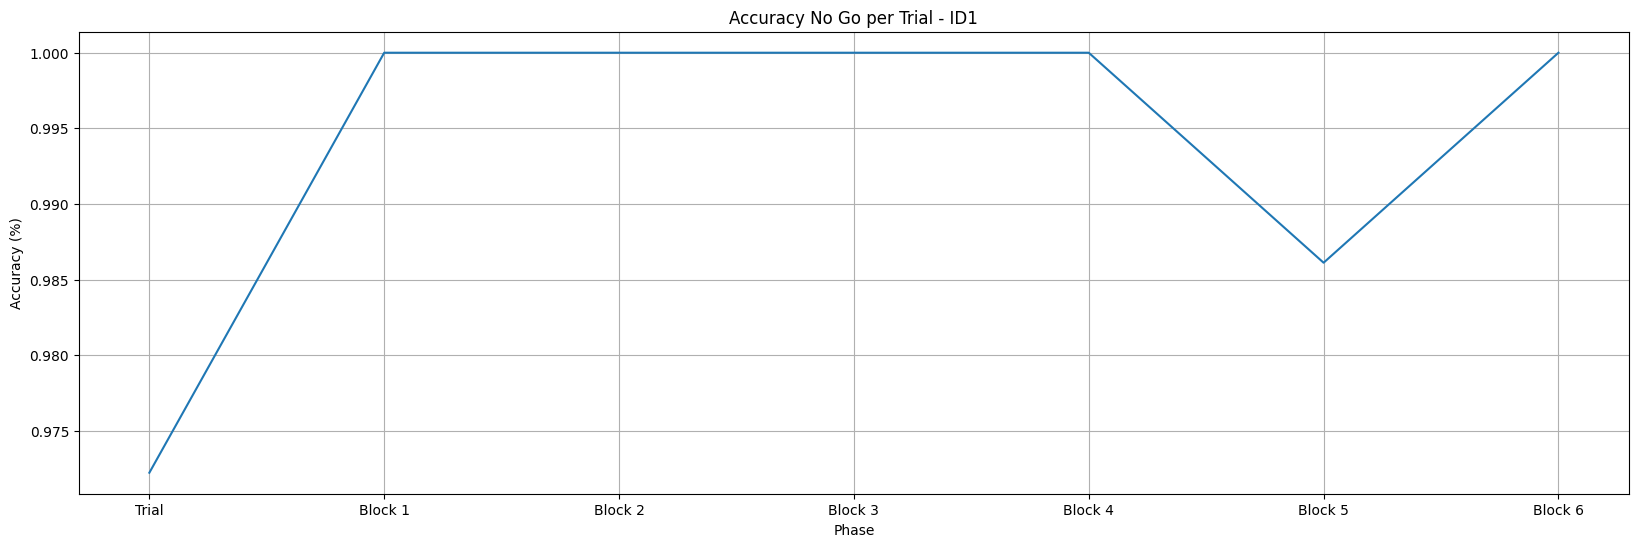

In [7]:
df = clean_all_data(df_id1)
plot_reaccion_time(df, id = 1)
all_accuracy_data = compute_both_accuracy(df)
plot_accuracy(data = all_accuracy_data, id = 1)
#plot_variability_rt(df, id)

#ID2

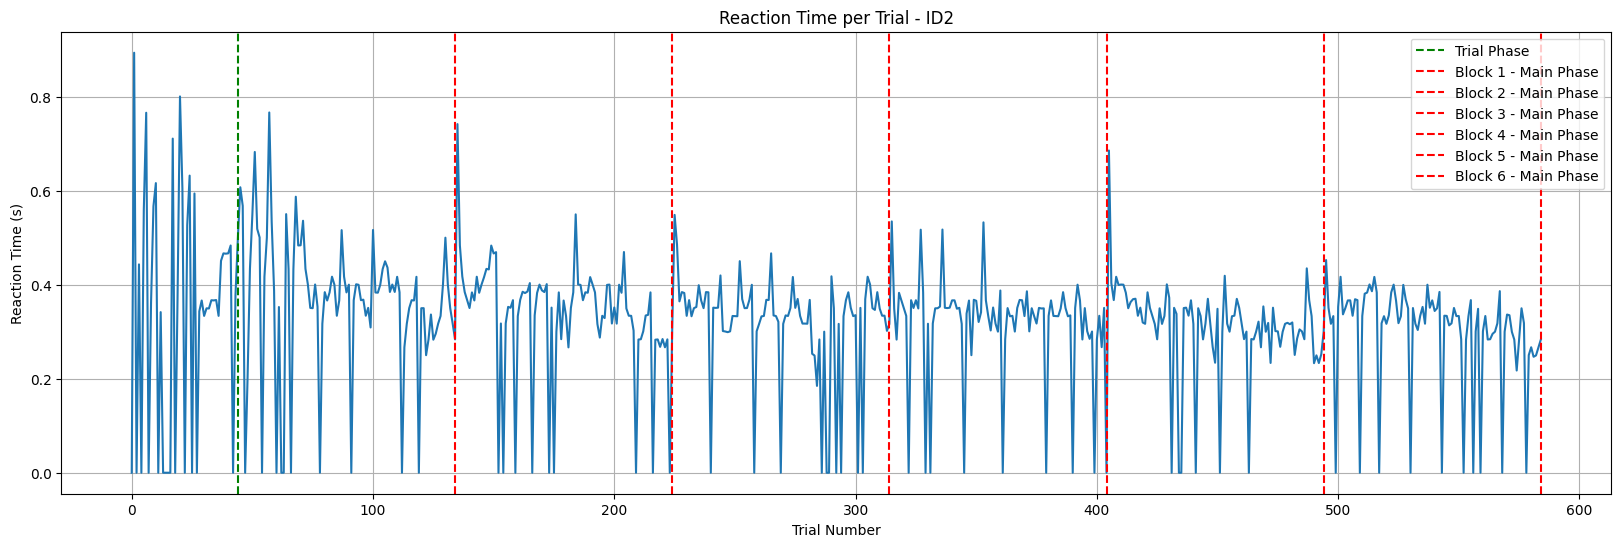

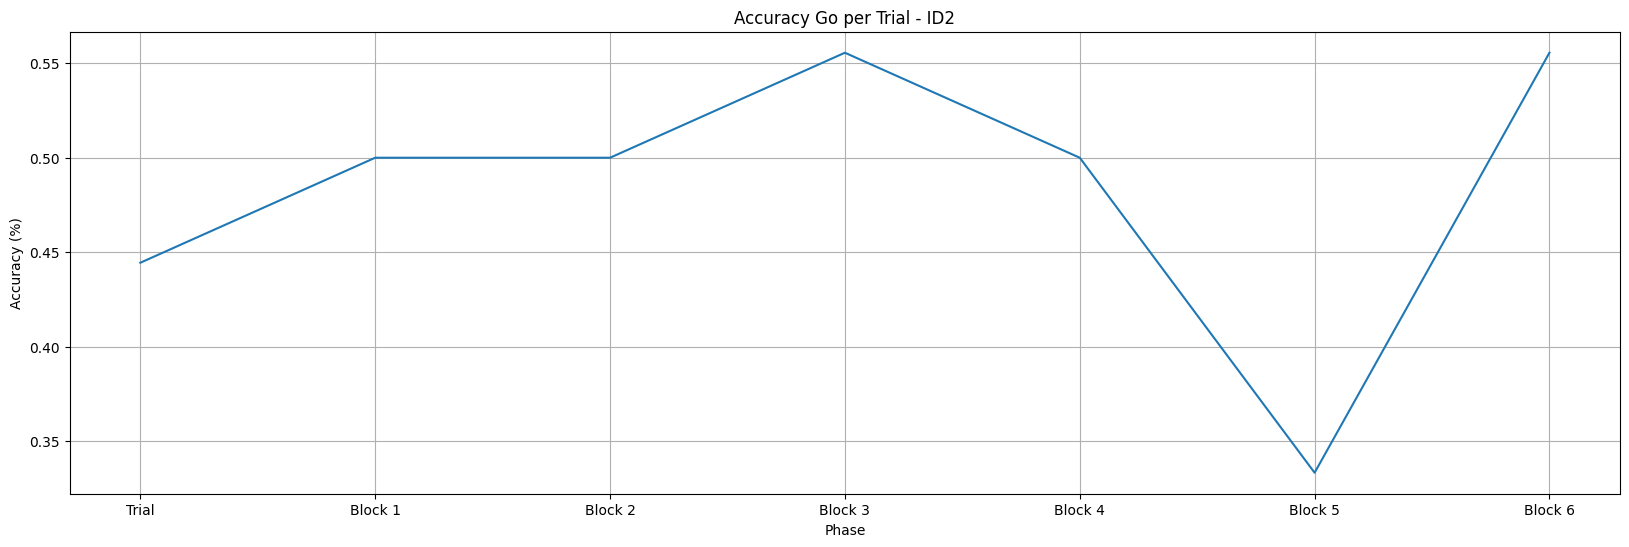

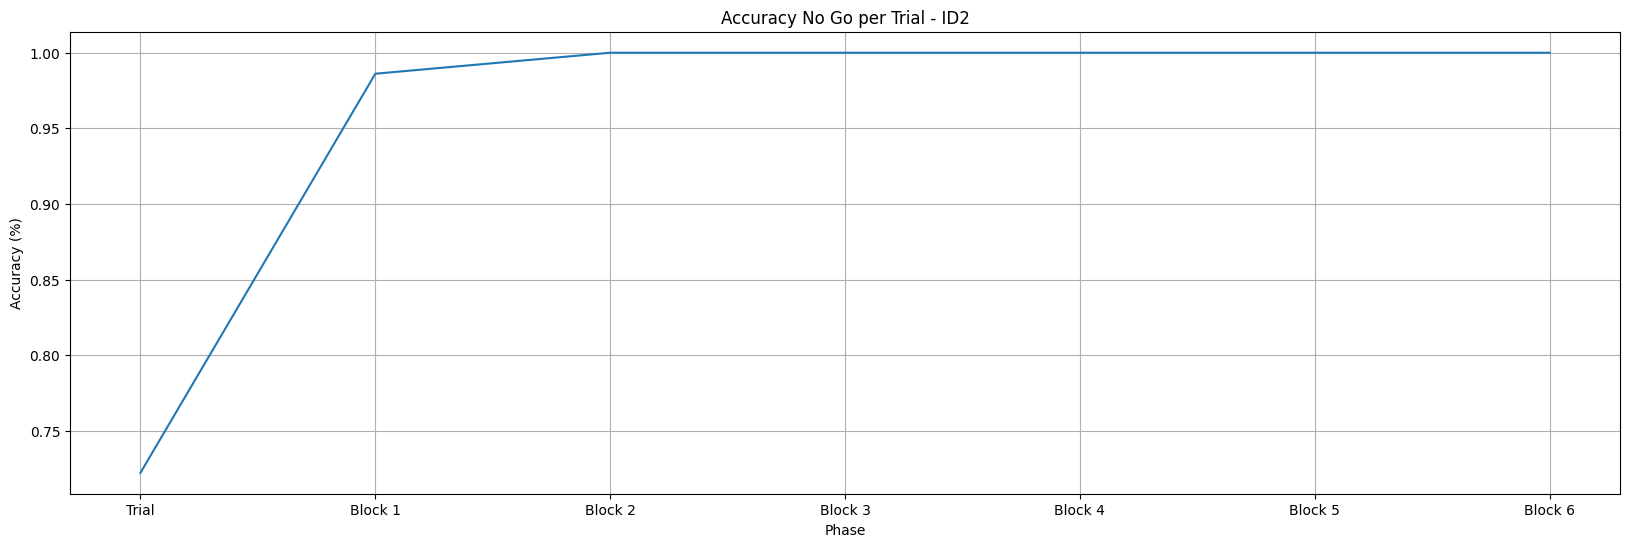

In [8]:
df = clean_all_data(df_id2)
plot_reaccion_time(df, id = 2)
all_accuracy_data = compute_both_accuracy(df)
plot_accuracy(data = all_accuracy_data, id = 2)

#ID3

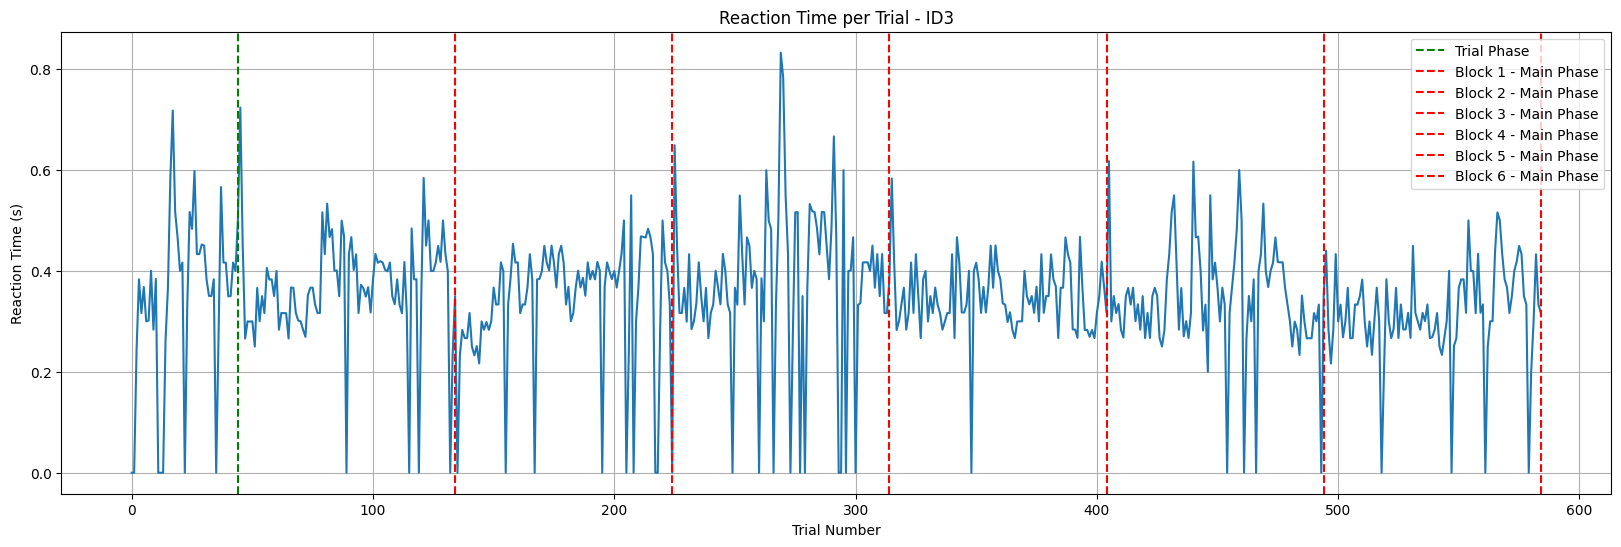

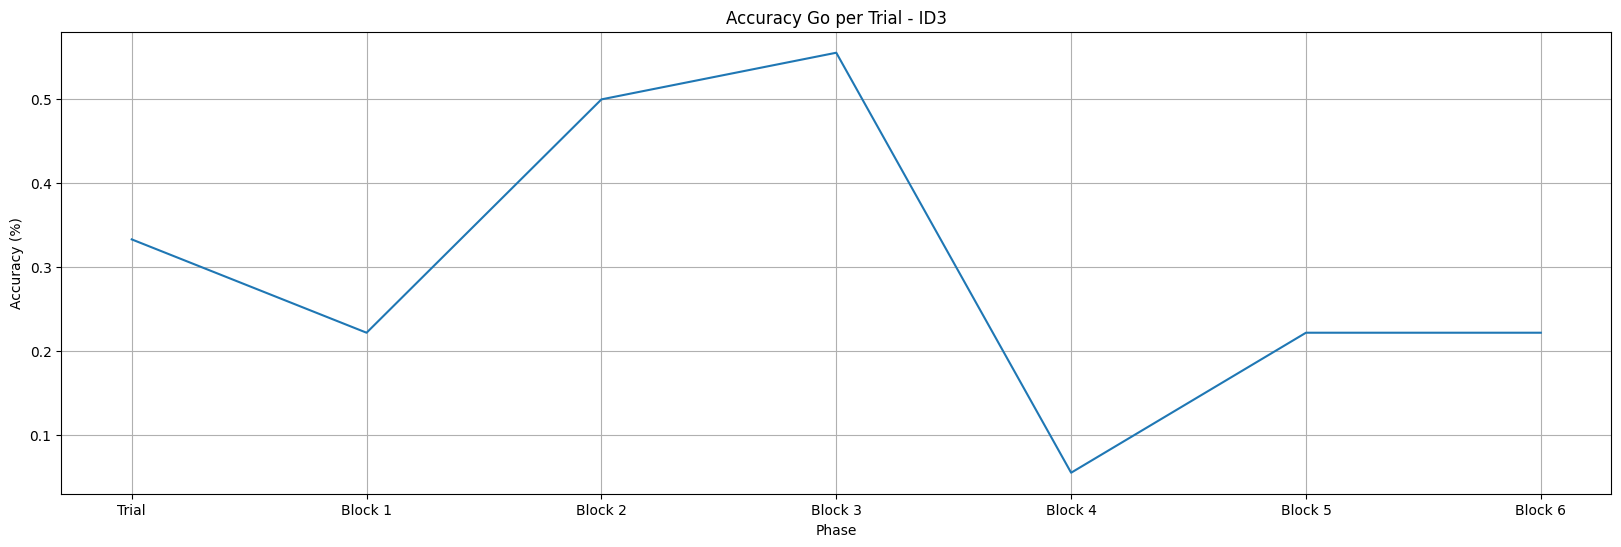

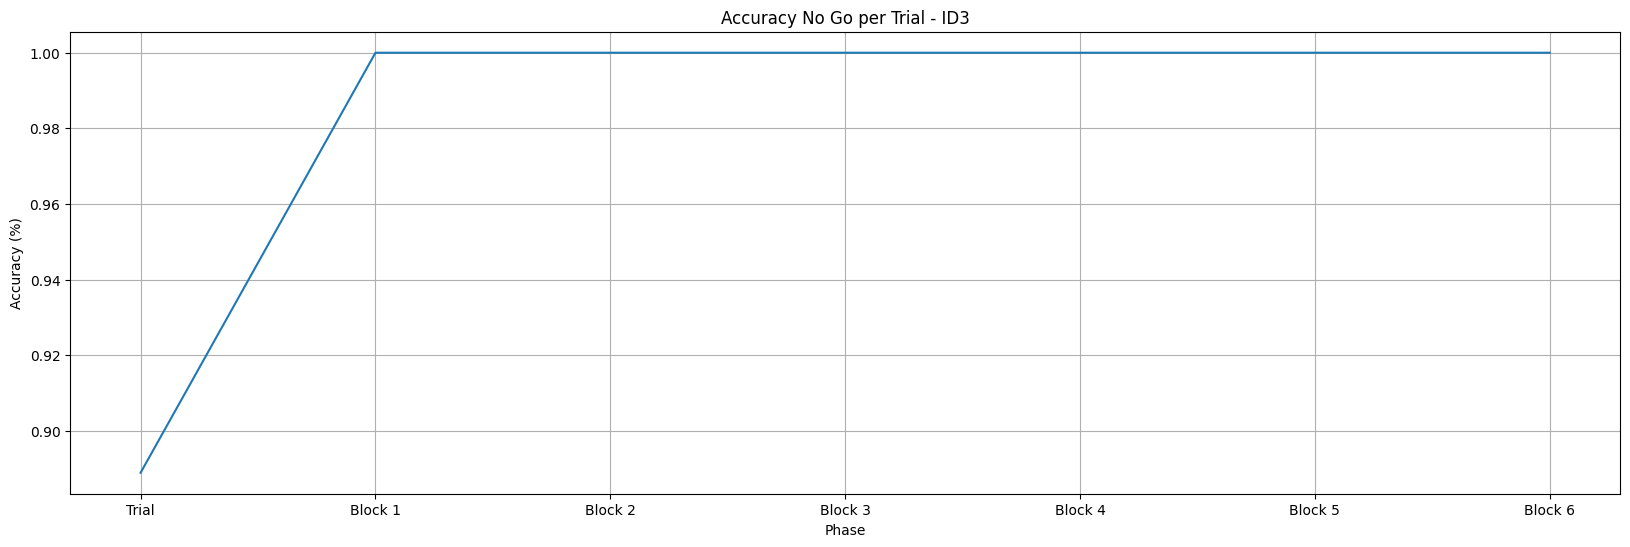

In [12]:
df = clean_all_data(df_id3)
plot_reaccion_time(df, id = 3)
all_accuracy_data = compute_both_accuracy(df)
plot_accuracy(data = all_accuracy_data, id = 3)

#ID4

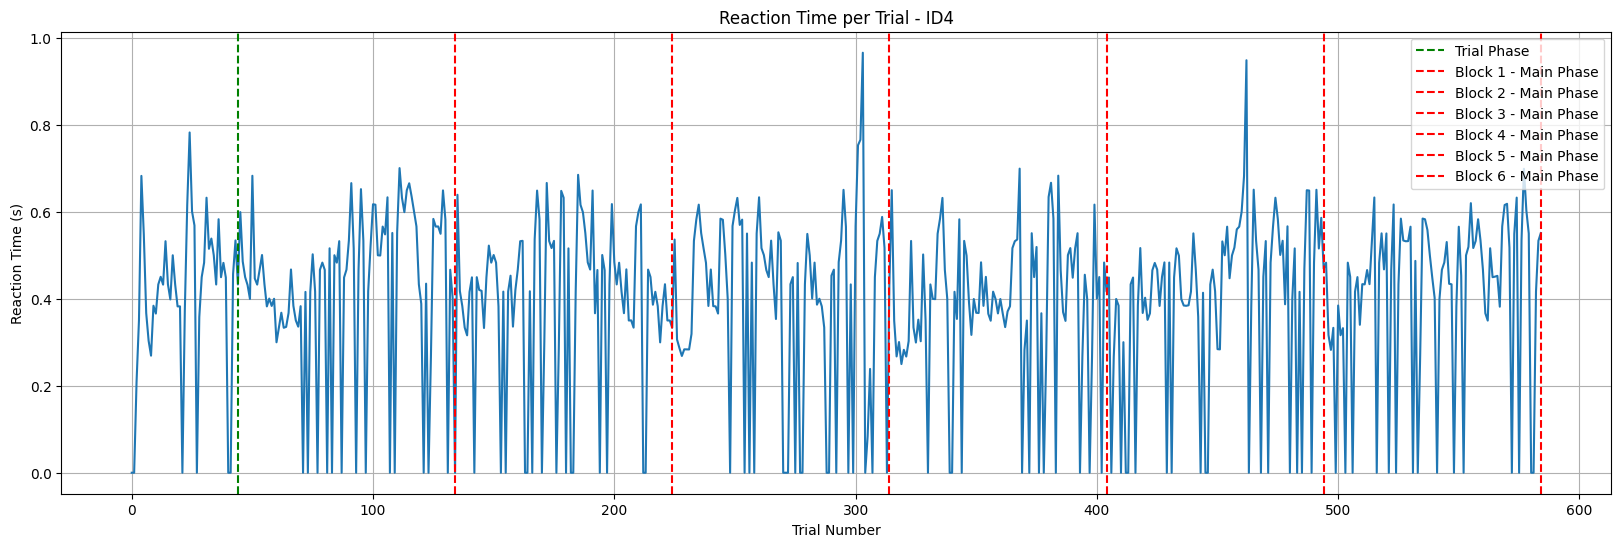

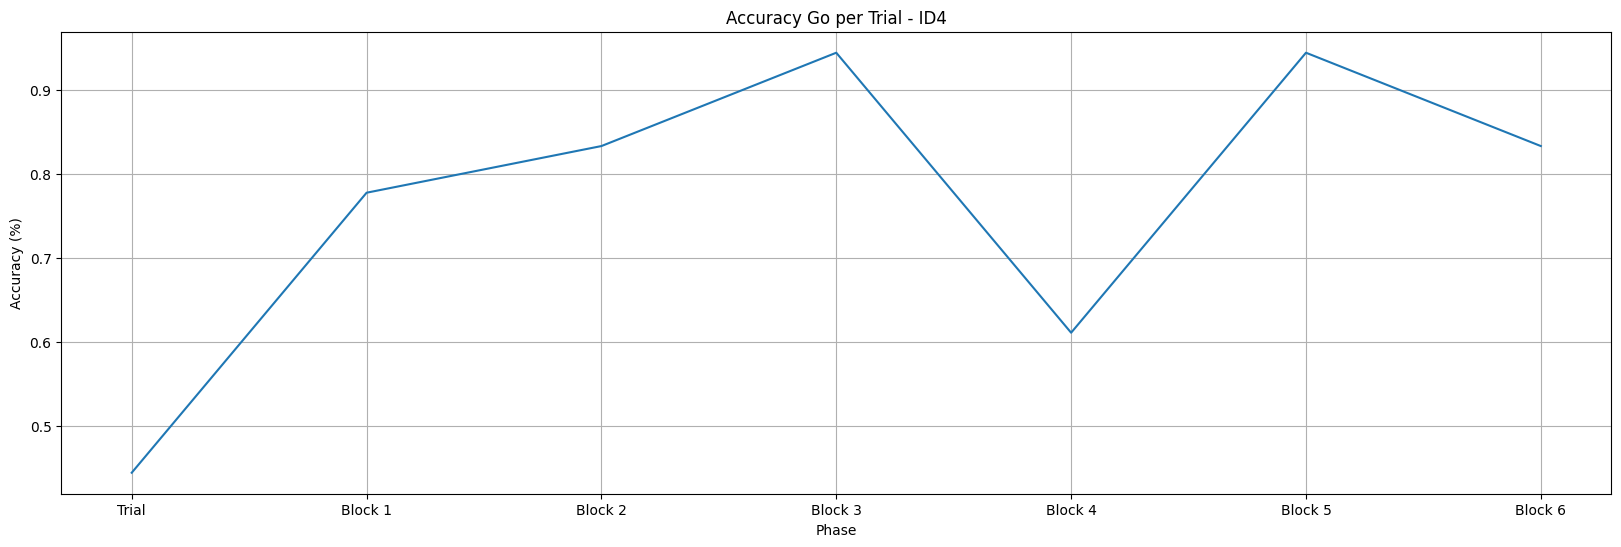

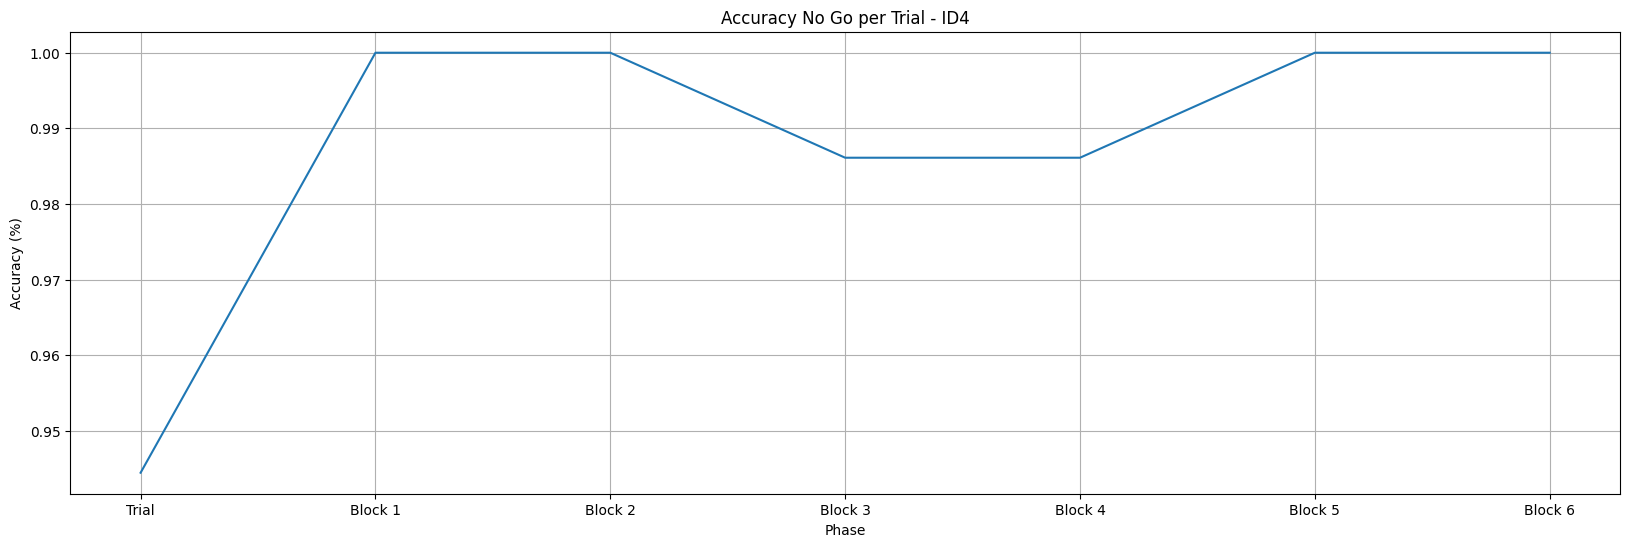

In [13]:
df = clean_all_data(df_id4)
plot_reaccion_time(df, id = 4)
all_accuracy_data = compute_both_accuracy(df)
plot_accuracy(data = all_accuracy_data, id = 4)